<a href="https://colab.research.google.com/github/Abhi-Nandan-Maity/CustomerSegmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# ---- Step 1: Load Dataset ----
# Use your own file or download from Kaggle ("Mall_Customers.csv")
data = pd.read_csv("Mall_Customers.csv")
print("✅ Data Loaded Successfully\n")
print(data.head())

✅ Data Loaded Successfully

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
# ---- Step 2: Select and Preprocess Features ----
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = data[features]


In [ ]:
# Scale the data for PCA and clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ---- Step 3: Dimensionality Reduction using PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance by PCA components:", pca.explained_variance_ratio_)


Explained variance by PCA components: [0.44266167 0.33308378]


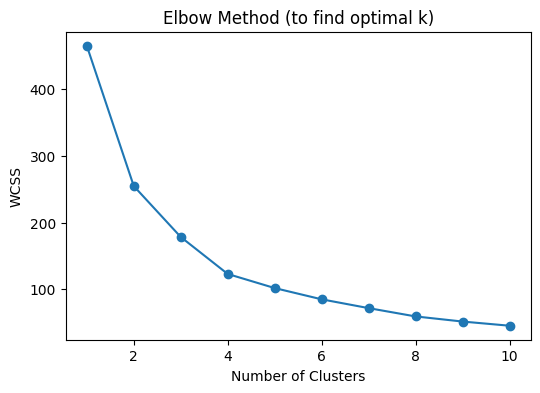

In [ ]:
# ---- Step 4: K-Means Clustering ----
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Elbow Method
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method (to find optimal k)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Fit final K-Means (k = 5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)

# Add cluster labels
data['KMeans_Cluster'] = y_kmeans

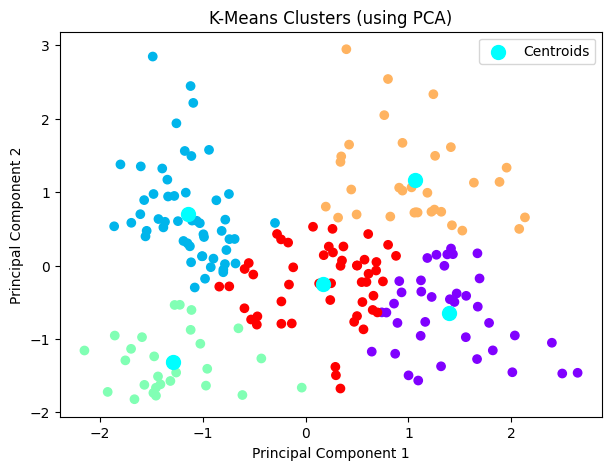

In [ ]:
# ---- Step 5: Visualize K-Means Result (2D PCA) ----
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],s=100,c='cyan',label='Centroids')
plt.legend()
plt.title('K-Means Clusters (using PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

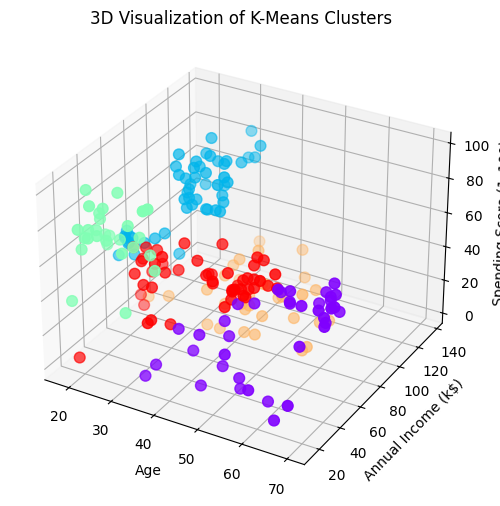

In [ ]:
# ---- Step 6: 3D Visualization (Age, Income, Spending) ----
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['Age'], X['Annual Income (k$)'], X['Spending Score (1-100)'],
           c=y_kmeans, cmap='rainbow', s=60)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1–100)')
plt.title('3D Visualization of K-Means Clusters')
plt.show()

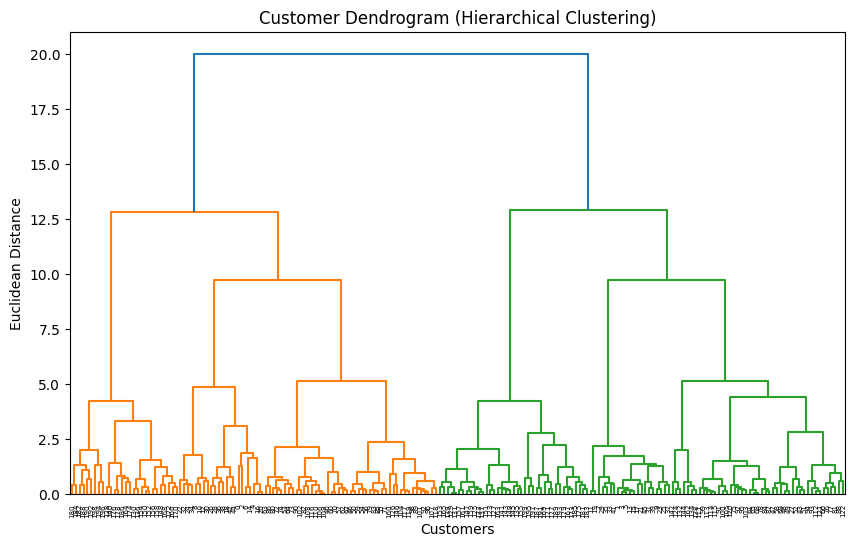

In [ ]:
# ---- Step 7: Hierarchical Clustering ----
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Customer Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)


# Add Hierarchical cluster labels
data['Hierarchical_Cluster'] = y_hc

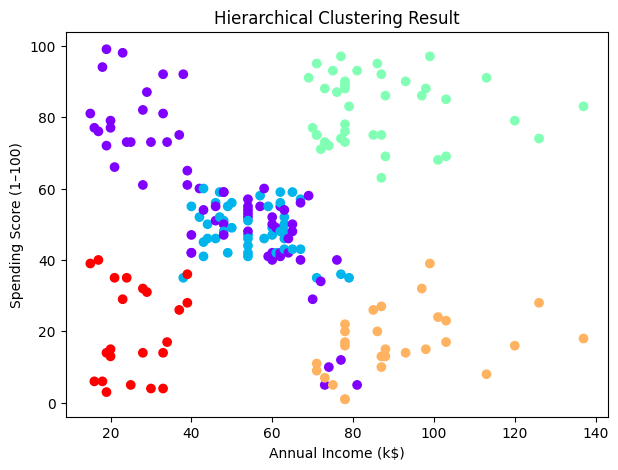

In [ ]:
# ---- Step 8: Compare Results ----
plt.figure(figsize=(7,5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
            c=y_hc, cmap='rainbow')
plt.title('Hierarchical Clustering Result')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.show()

In [ ]:
# ---- Step 9: Analyze and Print Insights ----
print("\n=== Cluster Summary (K-Means) ===")
summary = data.groupby('KMeans_Cluster')[features].mean().round(2)
print(summary)

print("\nInterpretation Tips:")
print("• Cluster with high Income & high Spending → Potential Premium Customers")
print("• Low Income & low Spending → Budget-conscious group")
print("• High Income but low Spending → Target with offers")
print("• Younger customers with high Spending → Brand-loyal youth segment")

print("\n✅ Project Completed Successfully!")


=== Cluster Summary (K-Means) ===
                  Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                   
0               57.87               41.82                   35.61
1               29.94               80.58                   74.00
2               24.75               27.82                   73.54
3               43.03               89.69                   17.34
4               38.88               53.68                   44.50

Interpretation Tips:
• Cluster with high Income & high Spending → Potential Premium Customers
• Low Income & low Spending → Budget-conscious group
• High Income but low Spending → Target with offers
• Younger customers with high Spending → Brand-loyal youth segment

✅ Project Completed Successfully!
